In [10]:
#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions import (
    getModel,
    kCrossVal,
    transfBestparam,
    kCrossValSingle,
    import_data,
)
from time import perf_counter
import pandas
import os

seed = 7
np.random.seed(seed)

In [11]:
file_path_HF = "../DATA/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)

NepoHF = 3000  # number of epochs for second NN: NN_HF

reaction_max = np.max(reaction_HF_test)
reaction_min = np.min(reaction_HF_test)
reaction_HF_test = (reaction_HF_test - reaction_min) / (
    reaction_max - reaction_min
)

permutation = np.random.permutation(len(reaction_HF_test))
Nhf = 15
reaction_HF = reaction_HF_test[permutation][0:Nhf]

In [12]:
U_HF_test = U_HF_test[:, -1, 44,44]

U_h_max_test = np.max(U_HF_test)
U_h_min_test = np.min(U_HF_test)
U_HF_test = (U_HF_test - U_h_min_test) / (U_h_max_test - U_h_min_test)

U_HF = U_HF_test[permutation][0:Nhf]

In [13]:
start = perf_counter()

reaction_final = np.vstack(
    (reaction_HF)
) 

MAX_EVAL = 2
name = "HF"  # I leave the same NN,  even if we use HF data instead of LF
K.clear_session()
bayes_trials = Trials()
opt_list = ["Adam", "Adamax"]
kernel_list = ["uniform", "glorot_uniform"]
aux_dic = {"opt": opt_list, "kernel_init": kernel_list}
space = {
    "nodes": hp.qloguniform("nodes", np.log(4), np.log(64), 2),
    "l2weight": hp.loguniform("l2weight", np.log(0.0001), np.log(100)),
    "lr": hp.loguniform("lr", np.log(0.0001), np.log(0.1)),
    "kernel_init": hp.choice("kernel_init", kernel_list),
    "opt": hp.choice("opt", opt_list),
}


def objective(params):
    K.clear_session()
    CVres = kCrossValSingle(Nhf, NepoHF, reaction_final, U_HF, params, name)
    return {"loss": CVres, "params": params, "status": STATUS_OK}


best_params = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=MAX_EVAL,
    trials=bayes_trials,
)

transfBestparam(best_params, aux_dic)
print(best_params)


1/1 [==============================] - 0s 73ms/step 

1/1 [==============================] - 0s 37ms/step 

1/1 [==============================] - 0s 32ms/step 

1/1 [==============================] - 0s 22ms/step 

1/1 [==============================] - 0s 31ms/step 

1/1 [==============================] - 0s 31ms/step 

1/1 [==============================] - 0s 34ms/step 

1/1 [==============================] - 0s 35ms/step 

1/1 [==============================] - 0s 24ms/step 

1/1 [==============================] - 0s 25ms/step 

1/1 [==============================] - 0s 38ms/step 

1/1 [==============================] - 0s 31ms/step 

1/1 [==============================] - 0s 19ms/step 

1/1 [==============================] - 0s 35ms/step 

1/1 [==============================] - 0s 47ms/step 

1/1 [==============================] - 0s 252ms/step                           

1/1 [==============================] - 0s 32ms/step                            

1/1 [=======================

In [14]:
####################    NN training and PREDICTION    #######################
start2 = perf_counter()

finalModel = getModel(
    best_params, name
)  # final model chosen according to the best paramters
hist = finalModel.fit(
    reaction_HF,
    U_HF,
    validation_data=(reaction_HF_test, U_HF_test),
    epochs=NepoHF,
    batch_size=Nhf,
    verbose=0,
    validation_freq=20,
)

UHF = finalModel.predict(reaction_HF_test)

stop = perf_counter()
elapsed = stop - start
print("Elapsed time: ", elapsed)
print("\nHF Model:")

elapsed2 = stop - start2
print("Elapsed time: ", elapsed2)
print("\nHF Model:")

2/2 [==============================] - 0s 0s/step
Elapsed time:  441.5752618000115

HF Model:
Elapsed time:  19.850662400000147

HF Model:


In [15]:
test_mse = np.mean(np.square(U_HF_test - UHF[:, 0]))
print(f"Test MSE: {test_mse}")

r2_HF = 1 - np.sum(np.square(U_HF_test - UHF[:, 0])) / np.sum(
    np.square(U_HF_test - np.mean(U_HF_test))
)
print(f"R^2: {r2_HF}")

Test MSE: 0.1186628327770216
R^2: -0.04826947290691752


2/2 [==============================] - 0s 0s/step


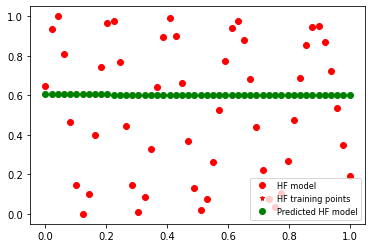

In [16]:
##################     Print LF, HF and LF-predicted models      ###################
plt.figure()
# plt.plot(mu_test, U_hf_test, 'b-', linewidth = 1.5, label = 'HF model')
# plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
plt.plot(reaction_HF_test, U_HF_test, "ro", linewidth=1.5, label="HF model")
plt.plot(reaction_HF, U_HF, "r*", markersize=5, label="HF training points")
plt.plot(
    reaction_HF_test,
    finalModel.predict(reaction_HF_test),
    "go",
    linewidth=3,
    label="Predicted HF model",
)
plt.legend(prop={"size": 8.3})
plt.show()

In [17]:
########################     SAVE the OUTPUT      ##########################
os.makedirs("NNHF_HF_15_new_activation")

R2_HF = pandas.DataFrame({"R2_HF": [r2_HF]})
MSE_test_HF = pandas.DataFrame({"MSE_test_HF": [test_mse]})


# R2_LF.to_csv('./Output_NNHF/r2_HF.txt', header=True, index=False, sep='\t', mode='a')
MSE_test_HF.to_csv(
    "./NNHF_HF_15_new_activation/test_mse.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
R2_HF.to_csv(
    "./NNHF_HF_15_new_activation/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
# MSE_test_LF.to_csv('./Output_NNHF/mse_LF_lhs.txt', header = True, index = False, sep = '\t', mode = 'a')
